#### Use the linear regression algorithm to model data generated by the make_regression function in Python. 

Construct data sets with 

## a) 100 samples, 1 feature with noise 10

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # MATLAB-like way of plotting

# sklearn package for machine learning in python:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
# generate regression data set
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=0)

In [20]:
# split the data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 1/3, random_state=0)

In [24]:
# fit the linear least-squres regression line to the training data:
regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [25]:
# The coefficients
print('Coefficients: ', regr.coef_)

# The intercept
print('Intercept: ', regr.intercept_)

# The mean squared error
print('Mean squared error: %.8f'
% mean_squared_error(y_test, regr.predict(X_test)))

# The R^2 value:
print('Coefficient of determination: %.2f'
% r2_score(y_test, regr.predict(X_test)))

Coefficients:  [43.61413082]
Intercept:  -0.4292189542298582
Mean squared error: 104.81530217
Coefficient of determination: 0.94


Text(0, 0.5, 'y')

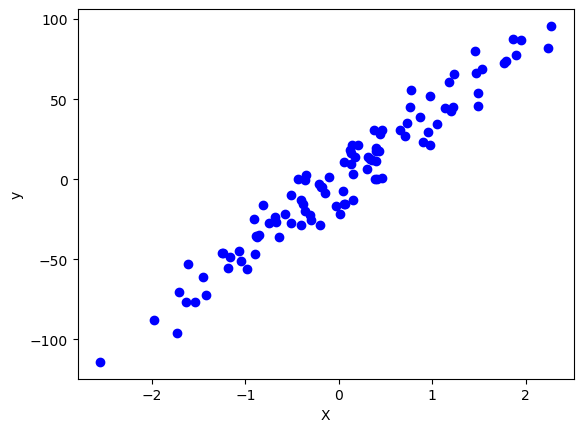

In [26]:
# visualise initial data set
fig1, ax1 = plt.subplots()
ax1.scatter(X, y, color='blue')
ax1.set_xlabel('X')
ax1.set_ylabel('y')

### b) 400 samples, 1 feature with noise 40.

In [4]:
# generate regression data set
X, y = make_regression(n_samples=400, n_features=1, noise=40, random_state=0)

Text(0, 0.5, 'y')

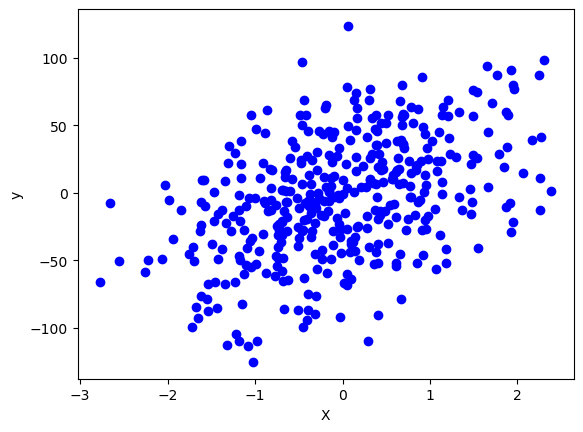

In [5]:
# visualise initial data set
fig1, ax1 = plt.subplots()
ax1.scatter(X, y, color='blue')
ax1.set_xlabel('X')
ax1.set_ylabel('y')

### c) 400 samples, 2 feature with noise 40.

In [15]:
# generate regression data set
X, y = make_regression(n_samples=400, n_features=2, noise=40, random_state=0)

Text(0, 0.5, 'y')

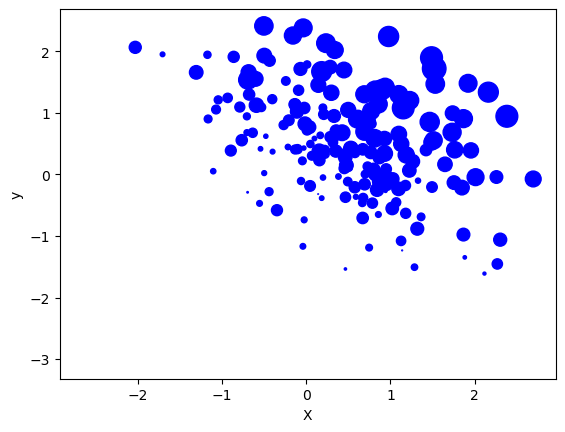

In [16]:
# visualise initial data set
fig1, ax1 = plt.subplots()
ax1.scatter(X[:,0], X[:,1], y, color = 'blue')
#ax1.scatter(X, y, color='blue')
ax1.set_xlabel('X')
ax1.set_ylabel('y')

### d) 400 samples, 5 feature with noise 40


### e) Experiment with the make_regression function to construct different data sets and apply the linear regression algorithm.

In [38]:
def experiment(n_samples, n_features, noise, bias=0, plot=False):
    print(f"\n--- Experiment: samples={n_samples}, features={n_features}, noise={noise} ---")
    
    X, y = make_regression(n_samples=n_samples,
                           n_features=n_features,
                           noise=noise,
                           bias=bias,
                           random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R² Score:", r2_score(y_test, y_pred))

    # 3D plot if 2D features
    if plot and n_features == 2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X[:,0], X[:,1], y, color='blue')
        X1, X2 = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 10),
                             np.linspace(X[:,1].min(), X[:,1].max(), 10))
        Z = model.coef_[0]*X1 + model.coef_[1]*X2 + model.intercept_
        ax.plot_surface(X1, X2, Z, alpha=0.5, color='red')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('y')
        plt.title("Regression Plane")
        plt.tight_layout()
        plt.show()



--- Experiment: samples=100, features=2, noise=10 ---
Coefficients: [85.3090942  74.54912666]
Intercept: -0.41469021863202826
Mean Squared Error: 83.97933931729537
R² Score: 0.9938741454031831


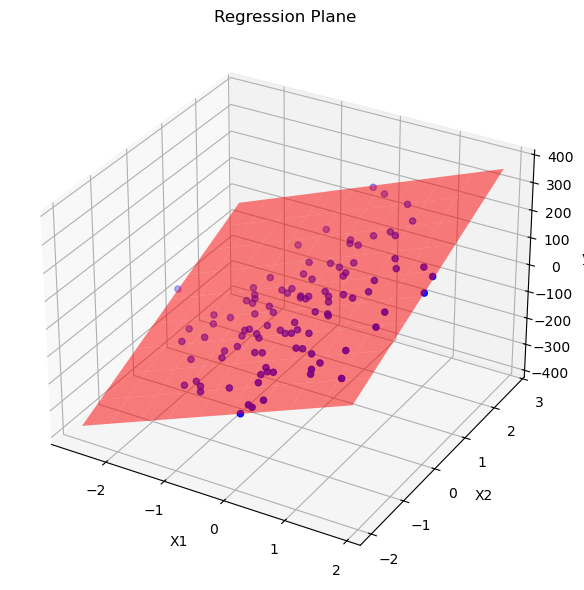

In [39]:
experiment(n_samples=100, n_features=2, noise=10, plot=True)


--- Experiment: samples=400, features=2, noise=10 ---
Coefficients: [32.52511476 84.43552963]
Intercept: 1.2814090730144034
Mean Squared Error: 105.65118054564113
R² Score: 0.9864466577545685


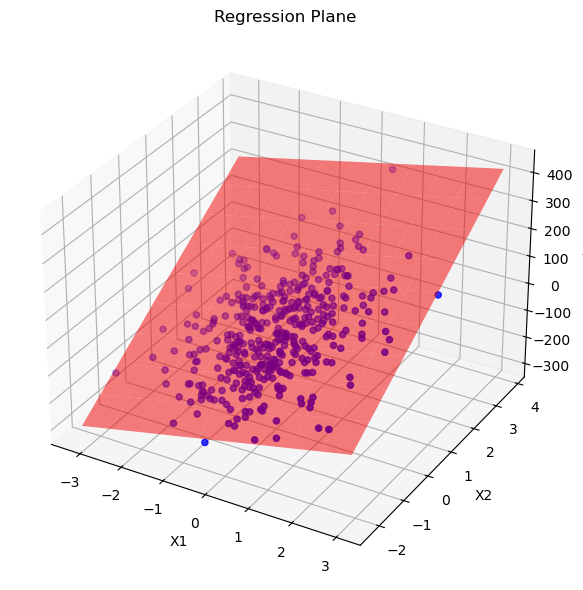

In [40]:
experiment(n_samples=400, n_features=2, noise=10, plot=True)


--- Experiment: samples=500, features=2, noise=100 ---
Coefficients: [20.6803206  21.04693286]
Intercept: 15.017422505745078
Mean Squared Error: 12262.848669760042
R² Score: -0.02760780681999364


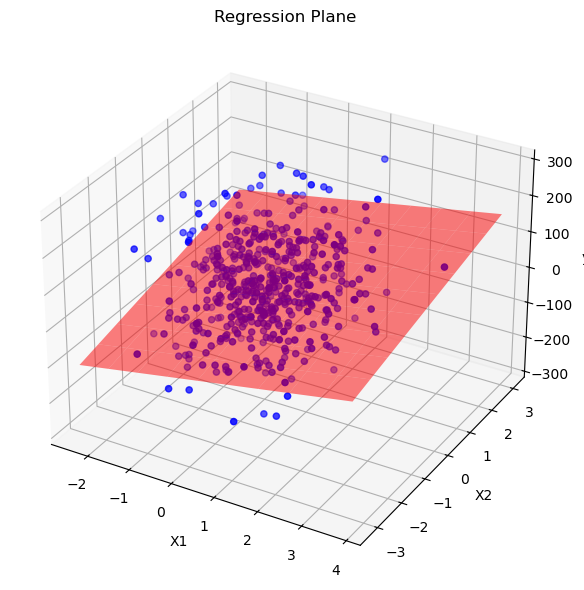

In [44]:
experiment(n_samples=500, n_features=2, noise=100, plot=True)